In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_coeffs

# Theory
**Check how RIPA2 paper computes M and N**

In [2]:
f_s = 300
f_nyquist = f_s / 2

f_target_vlf = 0.29
f_target_lf = 4

f_c_vlf = f_target_vlf / f_nyquist  # cutoff frequency for very low frequencies
f_c_lf = f_target_lf / f_nyquist    # cutoff frequency for low frequencies

m_vlf = 486*2+1 # full window length
n_vlf = 2

m_lf = 60*2+1   # full window length
n_lf = 4

### Using -3dB threshold

In [3]:
# compute -3dB cutoff for a given (M, N) pair
def compute_cutoff(window_length, poly_order, fs, power_threshold=0.5, fft_n=65536):
    
    # the S-G filter is an FIR filter so it can be fully described by its coefficients
    coeffs = savgol_coeffs(window_length, poly_order)

    # compute DTFT
    freqs = np.fft.rfftfreq(fft_n, d=1.0/fs)    # what frequencies
    H = np.fft.rfft(coeffs, n=fft_n)    # what the filter does at that frequency
    power = np.abs(H) ** 2  # how much power passes through at that frequency

    # find the index of the first frequency where power falls at or below the threshold
    below = np.where(power <= power_threshold)[0]
    if len(below) == 0:
        return None  # cutoff is beyond Nyquist — window is too short
    
    return freqs, H, np.abs(H), float(freqs[below[0]])


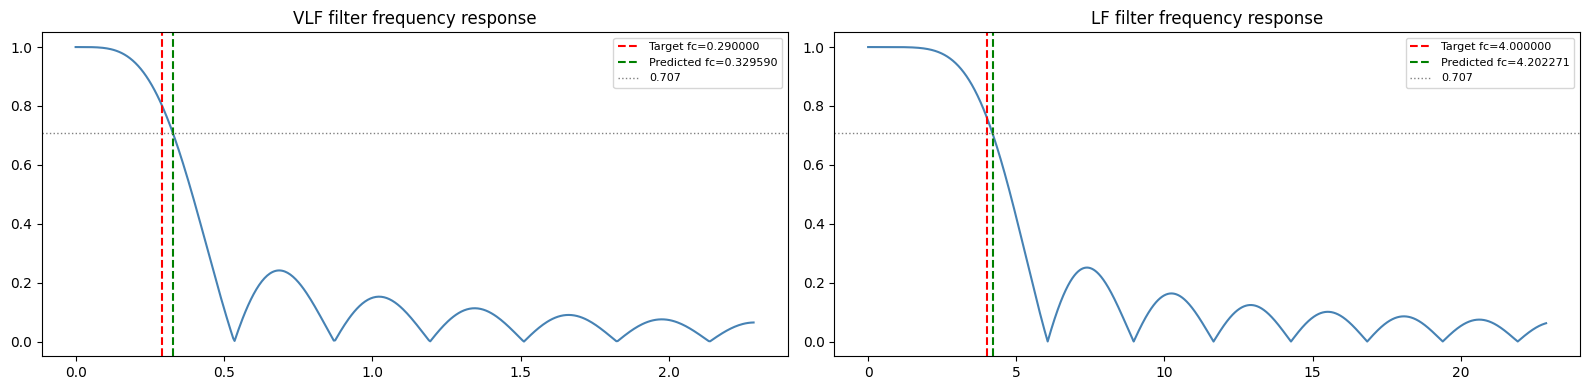

In [7]:
gain_threshold = 0.707  # -3dB point corresponds to gain = 0.707, -6dB point corresponds to gain = 0.25
power_threshold = gain_threshold ** 2

freqs_vlf, H_vlf, gain_vlf, pred_f_c_vlf = compute_cutoff(m_vlf, n_vlf, f_s, power_threshold)
freqs_lf, H_lf, gain_lf, pred_f_c_lf = compute_cutoff(m_lf, n_lf, f_s, power_threshold)

# plot the frequency response of the optimal filter
fig, ax = plt.subplots(1, 2, figsize=(16, 4))

ax[0].plot(freqs_vlf[:500], gain_vlf[:500], color='steelblue', lw=1.5)
ax[0].set_title('VLF filter frequency response')
ax[0].axvline(f_target_vlf, color='red', lw=1.5, ls='--', label=f'Target fc={f_target_vlf:.6f}')
ax[0].axvline(pred_f_c_vlf, color='green', lw=1.5, ls='--', label=f'Predicted fc={pred_f_c_vlf:.6f}')
ax[0].axhline(gain_threshold, color='gray', lw=1, ls=':', label=f'{gain_threshold:.3f}')
ax[0].legend(fontsize=8)

ax[1].plot(freqs_lf[:5000], gain_lf[:5000], color='steelblue', lw=1.5)
ax[1].set_title('LF filter frequency response')
ax[1].axvline(f_target_lf, color='red', lw=1.5, ls='--', label=f'Target fc={f_target_lf:.6f}')
ax[1].axvline(pred_f_c_lf, color='green', lw=1.5, ls='--', label=f'Predicted fc={pred_f_c_lf:.6f}')
ax[1].axhline(gain_threshold, color='gray', lw=1, ls=':', label=f'{gain_threshold:.3f}')
ax[1].legend(fontsize=8)

fig.tight_layout()

In [8]:
def frequency_response(window_length, poly_order, fs, fft_n=65536):
    coeffs = savgol_coeffs(window_length, poly_order)
    freqs = np.fft.rfftfreq(fft_n, d=1.0/fs)
    H     = np.fft.rfft(coeffs, n=fft_n)
    return freqs, np.abs(H)

# In Practice
**Recomputing M and N for a different sampling rate**

In [35]:
# compute -3dB cutoff for a given (M, N) pair
def compute_cutoff(window_length, poly_order, fs, fft_n=65536):
    
    # the S-G filter is an FIR filter so it can be fully described by its coefficients
    coeffs = savgol_coeffs(window_length*2+1, poly_order)

    # compute DTFT
    freqs = np.fft.rfftfreq(fft_n, d=1.0/fs)    # what frequencies
    H     = np.fft.rfft(coeffs, n=fft_n)    # what the filter does at that frequency
    power = np.abs(H) ** 2  # how much power passes through at that frequency

    # find the index of the first frequency where power falls at or below -3dB (power = 0.5)
    below = np.where(power <= 0.25)[0]
    if len(below) == 0:
        return None  # cutoff is beyond Nyquist — window is too short
    
    return float(freqs[below[0]])


In [36]:
# Shafer's approximation for S-G filter order
def approximate_m(f_c, n):

    # reordered from Shafer's approximation to solve for m
    m = round((n+1)/(3.2*f_c)+(4.6/3.2))

    # round up to an odd integer
    if m % 2 == 0:
        m += 1

    # Schafer's approximation is invalid for m < 25 and m < n
    if m < 25 or m < n:
        pass
    return m

In [37]:
# find best (M, N) pair for given target cutoff frequency
def grid_search_coefficients(max_order, target_f_c, half_window, fft_n, f_s):

    # grid search over (M, N) pairs
    best_result = None
    best_error  = np.inf
    results     = []   # store all evaluated (M, N, fc_actual, error)

    for poly_order in range(1, max_order + 1):

        # center the search window around the empirical estimate for this N
        # TODO: check if this needs to be half-window or full!
        M_center = approximate_m(target_f_c, poly_order)
        M_lo = max(poly_order + 2, M_center - half_window)   # M must be > N and odd
        M_hi = M_center + half_window

        for M in range(M_lo, M_hi + 1, 2):  # step by 2 to stay odd

            fc_actual = compute_cutoff(M, poly_order, f_s, fft_n)
            if fc_actual is None:   # cutoff beyond Nyquist
                continue

            error = abs(fc_actual - target_f_c)
            results.append((M, poly_order, fc_actual, error))

            if error < best_error:
                best_error  = error
                best_result = (M, poly_order, fc_actual, error)
    
    return best_result, results


In [38]:
# plot the frequency response of the optimal filter
def plot_frequency_response(window_length, poly_order, target_fc, fs, f_c_opt, fft_n=65536):
    
    coeffs = savgol_coeffs(window_length, poly_order)
    H = np.fft.rfft(coeffs, n=fft_n)
    freqs = np.fft.rfftfreq(fft_n, d=1.0/fs)
    power_db = 20 * np.log10(np.abs(H) + 1e-12)   # avoid log(0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Savitzky-Golay Filter  |  M={window_length}, N={poly_order}  "
                 f"|  Target fc={target_fc:.4f}  |  Actual fc={f_c_opt:.6f}",
                 fontsize=12, fontweight='bold')

    # left: linear scale (zoomed to passband)
    ax = axes[0]
    ax.plot(freqs, np.abs(H), color='steelblue', lw=1.5)
    ax.axvline(target_fc, color='red',    lw=1.5, ls='--', label=f'Target fc={target_fc:.6f}')
    ax.axvline(f_c_opt,    color='orange', lw=1.5, ls=':',  label=f'Actual fc={f_c_opt:.6f}')
    ax.axhline(1/np.sqrt(2), color='gray', lw=1, ls=':', label='−3 dB')
    ax.set_xlim(0, target_fc * 10)
    ax.set_xlabel('Frequency (cycles/sample)')
    ax.set_ylabel('|H(f)|')
    ax.set_title('Passband (linear)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # right: log scale (full spectrum)
    ax = axes[1]
    ax.plot(freqs, power_db, color='steelblue', lw=1.5)
    ax.axvline(target_fc, color='red', lw=1.5, ls='--', label=f'Target fc={target_fc:.6f}')
    ax.axvline(f_c_opt, color='orange', lw=1.5, ls=':',  label=f'Actual fc={f_c_opt:.6f}')
    ax.axhline(-3, color='gray', lw=1, ls=':', label='−3 dB')
    ax.set_xlim(0, 0.5)
    ax.set_ylim(-80, 5)
    ax.set_xlabel('Frequency (cycles/sample)')
    ax.set_ylabel('|H(f)| (dB)')
    ax.set_title('Full spectrum (dB)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [39]:
f_s = 300
f_nyquist = f_s / 2

f_target_vlf = 0.29
f_target_lf = 4

f_c_vlf = f_target_vlf / f_nyquist  # cutoff frequency for very low frequencies
f_c_lf = f_target_lf / f_nyquist    # cutoff frequency for low frequencies

m_vlf = 486
n_vlf = 2

m_lf = 60
n_lf = 4

Target cutoff:		 0.290000
Best (M, N):		 M=198, N=2
Actual cutoff:		 0.289764
Error:			 2.36e-04(0.08% of target)
No. of iterations:	 1515


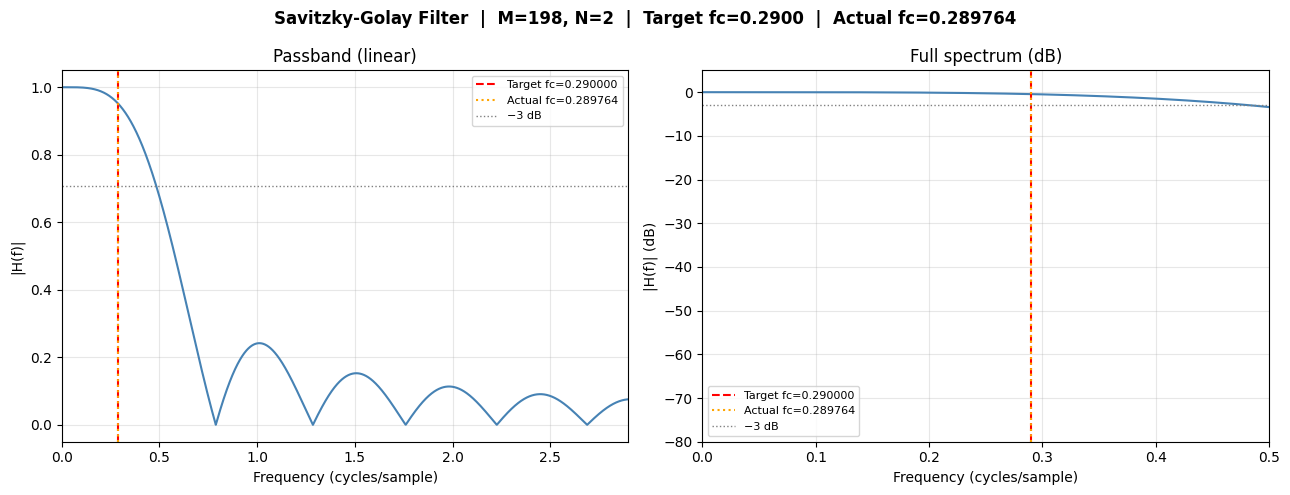

In [40]:
## VLF coefficients estimation

# configuration
f_s = 90
target_f_c = f_target_vlf    # normalized cutoff (cycles/sample), 0 < fc < 0.5
fft_n = 65536           # FFT size for frequency resolution
max_order = 10          # maximum polynomial order to search
search_half_window = 300      # search M in [estimate - this, estimate + this]

# grid search to find best coefficients for VLF cutoff
(M_opt, N_opt, fc_opt, best_error), results = grid_search_coefficients(max_order, target_f_c, search_half_window, fft_n, f_s)

print(f"Target cutoff:\t\t {target_f_c:.6f}")
print(f"Best (M, N):\t\t M={M_opt}, N={N_opt}")
print(f"Actual cutoff:\t\t {fc_opt:.6f}")
print(f"Error:\t\t\t {best_error:.2e}"
      f"({100*best_error/target_f_c:.2f}% of target)")
print(f"No. of iterations:\t {len(results)}")

# plot the frequency response of the optimal filter
plot_frequency_response(M_opt, N_opt, target_f_c, f_s, fc_opt, fft_n)

Target cutoff:		 4.000000
Best (M, N):		 M=14, N=2
Actual cutoff:		 3.966064
Error:			 3.39e-02(0.85% of target)
No. of iterations:	 447


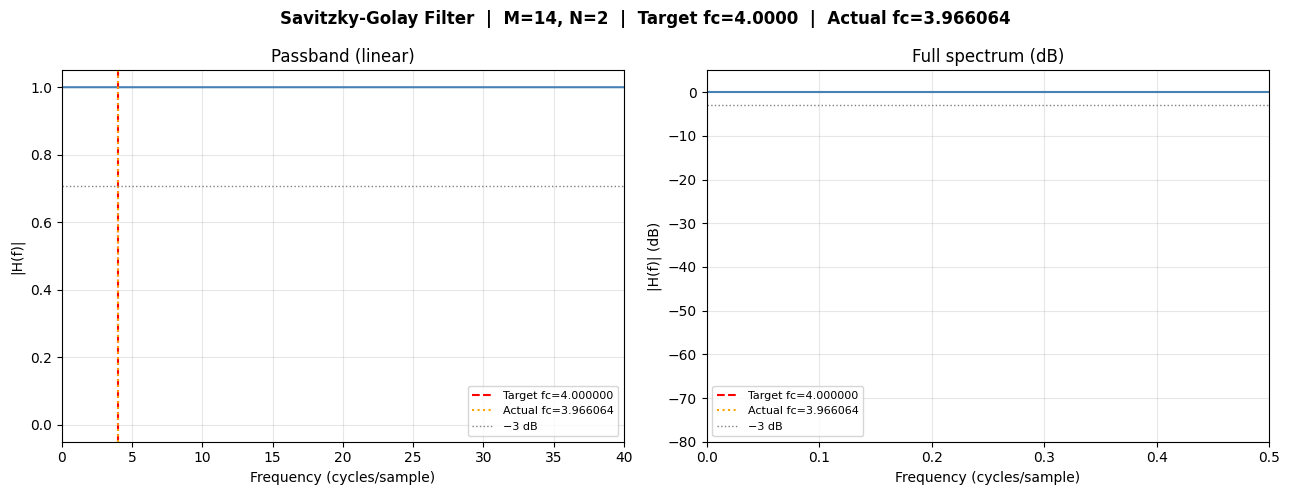

In [41]:
## LF coefficients estimation

# configuration
f_s = 90
target_f_c = f_target_lf    # normalized cutoff (cycles/sample), 0 < fc < 0.5
fft_n = 65536           # FFT size for frequency resolution
max_order = 6          # maximum polynomial order to search
search_half_window = 150      # search M in [estimate - this, estimate + this]

# grid search to find best coefficients for LF cutoff
(M_opt, N_opt, fc_opt, best_error), results = grid_search_coefficients(max_order, target_f_c, search_half_window, fft_n, f_s)

print(f"Target cutoff:\t\t {target_f_c:.6f}")
print(f"Best (M, N):\t\t M={M_opt}, N={N_opt}")
print(f"Actual cutoff:\t\t {fc_opt:.6f}")
print(f"Error:\t\t\t {best_error:.2e}"
      f"({100*best_error/target_f_c:.2f}% of target)")
print(f"No. of iterations:\t {len(results)}")

# plot the frequency response of the optimal filter
plot_frequency_response(M_opt, N_opt, target_f_c, fft_n, fc_opt, f_s)